# 🏰 Citadel Governance Hub - Testing Center

## Test your governance hub managed models, enabled through Azure API Management!

Use this Jupyter notebook with Python code snippets to verify proper functionality of your governance hub managed models when accessed through AI Gateway features in Azure API Management (APIM) part of AI Citadel Governance Hub.

> **Note:** This notebook assumes you have already set up your Citadel Governance Hub and have models deployed and managed through it. If you haven't done so, please refer to the [Citadel Governance Hub Deployment Guide](../guides/full-deployment-guide.md) or [Citadel Governance Hub Quick Deployment Guide](../guides/quick-deployment-guide.md) before proceeding.

<a id='0'></a>
### 0️⃣ Initialize notebook variables

Before running the tests, ensure you have set the following variables according to your environment:

In [1]:
import os
import sys, json, requests, time
sys.path.insert(1, '../shared')  # add the shared directory to the Python path
import utils
from apimtools import APIMClientTool

inference_api_version = "2024-05-01-preview"

targetInferenceApi = "models" # use 'models' for universal LLM API, or 'openai' for Azure OpenAI

governance_hub_resource_group = "rg-citadel-hub-dev-1"  ## specify the resource group name where the Governance Hub is located
# governance_hub_ai_gateway_name = "REPLACE"  ## specify the AI Gateway name in the Governance Hub
location = "swedencentral"

<a id='1'></a>
### 1️⃣ Verify the Azure CLI and the connected Azure subscription

The following commands ensure that you have the latest version of the Azure CLI and that the Azure CLI is connected to your Azure subscription.

In [2]:
output = utils.run("az account show", "Retrieved az account", "Failed to get the current az account")

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 16:01:13.829965 :0s]
👉🏽 Current user: admin@MngEnvMCAP805053.onmicrosoft.com
👉🏽 Tenant ID: fcbfc09a-8ad2-4370-929e-1946f1aa1f6f
👉🏽 Subscription ID: ad44bcb2-464c-463f-86b8-a89d43903cbf


<a id='0'></a>
### ⚙️ Initialize client tool for your APIM service

👉 An existing Citadel's Governance Hub deployment is expected with already on-baorded LLM models

In [3]:
try:
    apimClientTool = APIMClientTool(
        governance_hub_resource_group ## specify the resource group name where the API Management resource is located, or optionally add another parameter with the apim_resource_name
    )
    apimClientTool.initialize()
    apimClientTool.discover_api(targetInferenceApi) # use 'models' for inference API 'openai' for Azure OpenAI

    apim_resource_gateway_url = str(apimClientTool.apim_resource_gateway_url)
    azure_endpoint = str(apimClientTool.azure_endpoint)
    
    # Get supported models from the policy fragment
    supported_models = apimClientTool.get_policy_fragment_supported_models("set-backend-pools")
    utils.print_info(f"Supported models in APIM policy fragment 'set-backend-pools': {supported_models}")
    # model_name = supported_models[2]  # pick the third model from the supported models in the policy fragment

    if targetInferenceApi == "openai":
        chat_completions_url = f"{azure_endpoint}openai/deployments/{model_name}/chat/completions?api-version={inference_api_version}"
    else:  # models
        chat_completions_url = f"{azure_endpoint}models/chat/completions?api-version={inference_api_version}"
    utils.print_info(f"Chat Completion Endpoint: {chat_completions_url}")

    utils.print_info(f"Using the following API: {apimClientTool.api_id}")

    utils.print_ok(f"Testing tool initialized successfully!")
except Exception as e:
    utils.print_error(f"Error initializing APIM Client Tool: {e}")



⚙️ Running: az account show 
✅ Retrieved az account ⌚ 16:01:14.037734 :0s]
👉🏽 Current user: admin@MngEnvMCAP805053.onmicrosoft.com
👉🏽 Tenant ID: fcbfc09a-8ad2-4370-929e-1946f1aa1f6f
👉🏽 Subscription ID: ad44bcb2-464c-463f-86b8-a89d43903cbf
⚙️ Running: az resource list -g rg-citadel-hub-dev-1 --resource-type Microsoft.ApiManagement/service 
✅ Listing APIM Resources ⌚ 16:01:15.896078 :1s]
👉🏽 APIM Service Id: /subscriptions/ad44bcb2-464c-463f-86b8-a89d43903cbf/resourceGroups/rg-citadel-hub-dev-1/providers/Microsoft.ApiManagement/service/apim-bc2yajbbxycfw
👉🏽 APIM Gateway URL: https://apim-bc2yajbbxycfw.azure-api.net
👉🏽 Retrieved key 0 for subscription: 6989a6ad5c87ed004b070001
👉🏽 Retrieved key 1 for subscription: 6989a6ad5c87ed004b070002
👉🏽 Retrieved key 2 for subscription: master
👉🏽 Found API with id /subscriptions/ad44bcb2-464c-463f-86b8-a89d43903cbf/resourceGroups/rg-citadel-hub-dev-1/providers/Microsoft.ApiManagement/service/apim-bc2yajbbxycfw/apis/universal-llm-api and path models
👉🏽 

<a id='2'></a>
### 2️⃣ Create Citadel Access Contract using 🦾 Bicep

AI [Citadel Access Contracts](../guides/citadel-access-contracts.md) are configuration files that grant specific use-case access to governed AI services in the Governance Hub.

Below instructions will onboard a sample use case by creating a parameter file dynamically from notebook values and deploying using the Bicep templates in `bicep/infra/usecase-onboarding/`.

In [4]:
# Citadel Access Contract details
citadel_access_contract_name = f"crm-support-agent-access-contract-{time.strftime('%Y%m%d%H%M%S')}"
bicep_dir = "../bicep/infra/citadel-access-contracts"
template_file = os.path.join(bicep_dir, "main.bicep")
params_file = os.path.join(bicep_dir, "crm-support-agent-usecase-local.bicepparam")

# Create parameter file content with values from notebook
params_content = f"""using './main.bicep'

// ============================================================================
// CRM-Support-Agent Use Case - Onboarding Parameters (Generated from Notebook)
// ============================================================================

// Target APIM instance where APIs are published
param apim = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: '{apimClientTool.apim_resource_name}'
}}

// Target Key Vault for storing endpoint URLs and API keys
// Set useTargetAzureKeyVault to false if you don't want to use Key Vault
param keyVault = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: 'kv-test-usecase'  // Update this to your Key Vault name if using Key Vault
}}

// Whether to store secrets in Key Vault (true) or output them directly (false)
param useTargetAzureKeyVault = false  // Set to true if you have a Key Vault configured

// Use case identification for naming and organization
param useCase = {{
  businessUnit: 'CRM'
  useCaseName: 'SupportAgent'
  environment: 'DEV'
}}

// Mapping of service codes to their API names in APIM
// These API names must already exist in your APIM instance
param apiNameMapping = {{
  LLM: [
    'universal-llm-api', 'azure-openai-api'
  ]
}}

// Services required for this use case
param services = [
  {{
    code: 'LLM'
    endpointSecretName: 'TEST-OPENAI-ENDPOINT'
    apiKeySecretName: 'TEST-OPENAI-KEY'
    policyXml: ''  // Uses default policy
  }}
]

// Optional: Product terms of service
param productTerms = 'This is a test deployment from the testing notebook.'
"""

# Write the parameter file
utils.print_info(f"Creating parameter file: {params_file}")
with open(params_file, 'w') as f:
    f.write(params_content)

utils.print_ok(f"Parameter file created successfully!")

# Display the parameter file content
# utils.print_info("Parameter file content:")
# print(params_content)

# Deploy using az deployment sub (subscription-level deployment as per the template)
deployment_cmd = f"az deployment sub create --name {citadel_access_contract_name} --location {location} --template-file {template_file} --parameters {params_file}"

utils.print_info(f"Running deployment command...")
output = utils.run(
    deployment_cmd,
    f"Deployment '{citadel_access_contract_name}' succeeded",
    f"Deployment '{citadel_access_contract_name}' failed"
)

# Check deployment success and process outputs
if output.success:
    utils.print_ok("Deployment completed successfully!")
    
    # Re-initialize to pick up any changes
    apimClientTool.initialize()
    
    # Get the API key from the last created subscription
    if apimClientTool.apim_subscriptions:
        api_key = apimClientTool.apim_subscriptions[-1].get("key")
        utils.print_ok(f"API Key retrieved from subscription")
    else:
        utils.print_error("No APIM subscriptions found after deployment")
    
    # Parse and display deployment outputs if available
    if output.json_data and output.json_data != {}:
        utils.print_info(f"Citadel Access Contract Outputs:")
        outputs = output.json_data.get('properties', {}).get('outputs', {})
        if outputs:
            for key, value in outputs.items():
                masked_value = utils.mask_sensitive_values(value.get('value'))
                utils.print_ok(f"  {key}: {masked_value}")
        else:
            utils.print_warning("Deployment succeeded but no outputs were returned")
            utils.print_info("This is normal for some deployments")
    else:
        utils.print_warning("Deployment succeeded but output parsing failed or returned empty")
        utils.print_info(f"Raw output text (first 500 chars): {output.text[:500]}")
else:
    utils.print_error(f"Deployment failed!")
    utils.print_error(f"Error details: {output.text}")

👉🏽 Creating parameter file: ../bicep/infra/citadel-access-contracts/crm-support-agent-usecase-local.bicepparam
✅ Parameter file created successfully! ⌚ 16:01:21.673761 
👉🏽 Running deployment command...
⚙️ Running: az deployment sub create --name crm-support-agent-access-contract-20260216160121 --location swedencentral --template-file ../bicep/infra/citadel-access-contracts/main.bicep --parameters ../bicep/infra/citadel-access-contracts/crm-support-agent-usecase-local.bicepparam 
✅ Deployment 'crm-support-agent-access-contract-20260216160121' succeeded ⌚ 16:02:02.739262 :41s]
✅ Deployment completed successfully! ⌚ 16:02:02.739699 
⚙️ Running: az account show 
✅ Retrieved az account ⌚ 16:02:02.987054 :0s]
👉🏽 Current user: admin@MngEnvMCAP805053.onmicrosoft.com
👉🏽 Tenant ID: fcbfc09a-8ad2-4370-929e-1946f1aa1f6f
👉🏽 Subscription ID: ad44bcb2-464c-463f-86b8-a89d43903cbf
👉🏽 APIM Service Id: /subscriptions/ad44bcb2-464c-463f-86b8-a89d43903cbf/resourceGroups/rg-citadel-hub-dev-1/providers/Micro

<a id='requests'></a>
### 🧪 Test the API using a direct HTTP call


In [5]:
model_name = supported_models[2] # pick the model from the supported models in the policy fragment
utils.print_info(f"Using model: {model_name}")

messages={"model": model_name, "messages":[
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}


response = requests.post(chat_completions_url, headers = {'api-key':api_key}, json = messages)
utils.print_response_code(response)
utils.print_info(f"headers {response.headers}")
utils.print_info(f"x-ms-region: {response.headers.get("x-ms-region")}") # this header is useful to determine the region of the backend that served the request
if (response.status_code == 200):
    data = json.loads(response.text)
    print("💬 ", data.get("choices")[0].get("message").get("content"))
else:
    utils.print_error(response.text)

👉🏽 Using model: gpt-4o
Response status: 200 - OK
👉🏽 headers {'Content-Length': '1357', 'Content-Type': 'application/json', 'Date': 'Mon, 16 Feb 2026 15:02:07 GMT', 'apim-request-id': '921396c1-81c1-4ddd-836a-981945a97e6f', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains; preload', 'X-Content-Type-Options': 'nosniff', 'x-ms-region': 'Sweden Central', 'x-ratelimit-remaining-requests': '99', 'x-ratelimit-limit-requests': '100', 'x-ratelimit-remaining-tokens': '99980', 'x-ratelimit-limit-tokens': '100000', 'azureml-model-session': 'd20260216031804-789cc0d497ac', 'x-ms-rai-invoked': 'true', 'x-request-id': 'e350e400-e36c-4aa4-9653-b433dd198089', 'x-ms-client-request-id': 'Not-Set', 'x-ms-deployment-name': 'gpt-4o', 'remaining-tokens': '335', 'consumed-tokens': '65', 'Request-Context': 'appId=cid-v1:9e53266c-270d-4ce5-97f8-643cae497daa'}
👉🏽 x-ms-region: Sweden Central
💬  Oh sure, because I'm totally sitting here with a clock in front of me. Why don't you just check the time

<a id='requests'></a>
### 🧪 Send multiple requests within one minute to surpass the established token rate limit


In [6]:
import requests, json, time

# Run for 1 minute (60 seconds)
api_runs = []
start_time = time.time()
run_count = 0
messages={"messages":[
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}

model_name = supported_models[2] # pick the model from the supported models in the policy fragment
utils.print_info(f"Using model: {model_name}")

api_key = apimClientTool.apim_subscriptions[-1].get("key") # Get the last created subscription key for the access contract
chat_completions_url = f"{azure_endpoint}/openai/deployments/{model_name}/chat/completions?api-version={inference_api_version}"

print(f"🕐 Starting API calls for 1 minute...")
print(f"Start time: {time.strftime('%H:%M:%S', time.localtime(start_time))}")

while (time.time() - start_time) < 60:  # Run for 60 seconds
    run_count += 1    
    call_start_time = time.time()
    response = requests.post(chat_completions_url, headers = {'api-key':api_key}, json = messages)
    elapsed_time = time.time() - start_time
    
    if (response.status_code == 200):
        print(f"▶️ Run: {run_count} | {elapsed_time:.1f}s | status: {response.status_code} ✅")
        data = json.loads(response.text)
        total_tokens = data.get("usage").get("total_tokens")
        print(f"    consumed tokens: {response.headers.get('consumed-tokens')}, remaining tokens: {response.headers.get('remaining-tokens')}")
    else:
        print(f"▶️ Run: {run_count} | {elapsed_time:.1f}s | status: {response.status_code} ⛔")        
        print(f"    error: {response.text}")
        total_tokens = 0
    
    api_runs.append((call_start_time, total_tokens, response.status_code))
    time.sleep(0.1) # Small delay to prevent overwhelming the API

end_time = time.time()
total_duration = end_time - start_time
print(f"\n🏁 Completed {run_count} API calls in {total_duration:.1f} seconds")
print(f"Average rate: {run_count / total_duration:.2f} calls/second")


👉🏽 Using model: gpt-4o
🕐 Starting API calls for 1 minute...
Start time: 16:02:07
▶️ Run: 1 | 1.6s | status: 200 ✅
    consumed tokens: 79, remaining tokens: 256
▶️ Run: 2 | 3.8s | status: 200 ✅
    consumed tokens: 83, remaining tokens: 173
▶️ Run: 3 | 6.3s | status: 200 ✅
    consumed tokens: 96, remaining tokens: 77
▶️ Run: 4 | 7.7s | status: 200 ✅
    consumed tokens: 69, remaining tokens: 8
▶️ Run: 5 | 9.5s | status: 200 ✅
    consumed tokens: 72, remaining tokens: 0
▶️ Run: 6 | 9.8s | status: 429 ⛔
    error: { "statusCode": 429, "message": "Token limit is exceeded. Try again in 51 seconds." }
▶️ Run: 7 | 10.1s | status: 429 ⛔
    error: { "statusCode": 429, "message": "Token limit is exceeded. Try again in 50 seconds." }
▶️ Run: 8 | 10.4s | status: 429 ⛔
    error: { "statusCode": 429, "message": "Token limit is exceeded. Try again in 50 seconds." }
▶️ Run: 9 | 10.7s | status: 429 ⛔
    error: { "statusCode": 429, "message": "Token limit is exceeded. Try again in 50 seconds." }
▶

<a id='plot'></a>
### 🔍 Analyze Token Rate limiting results


Calls: 153 | Success: 5 | 429s: 148


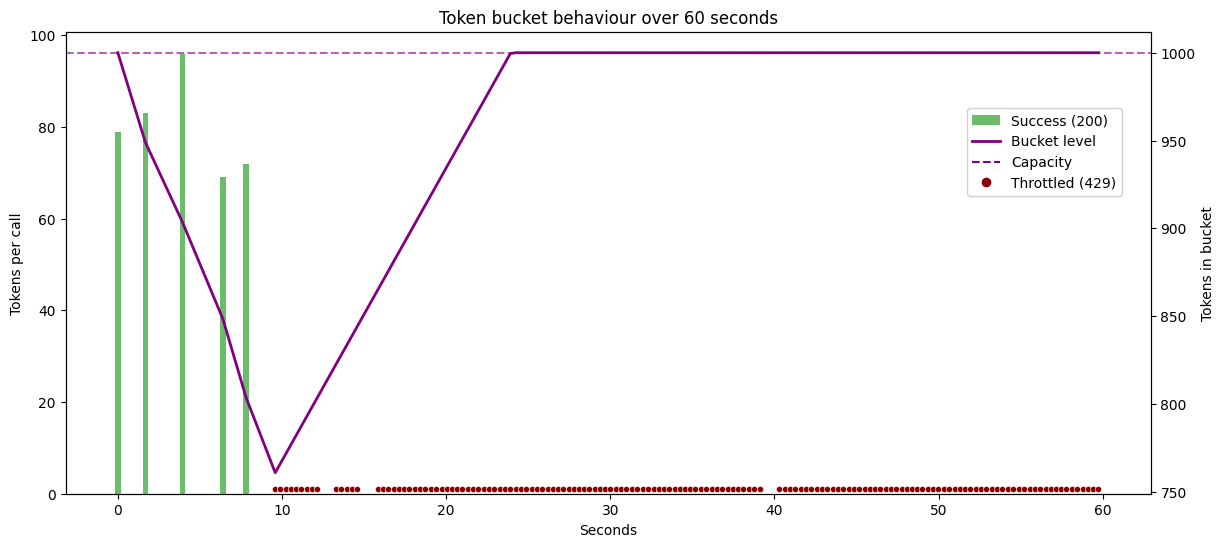

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if 'api_runs' in locals() and api_runs:
    calls = [(t - api_runs[0][0], tokens or 0, status) for t, tokens, status in api_runs]
    capacity = 1000
    refill = capacity / 60
    bucket = capacity
    last_time = 0.0
    times, usage, status_codes, levels = [], [], [], []

    for call_time, tokens, status in calls:
        bucket = min(capacity, bucket + (call_time - last_time) * refill)
        levels.append(bucket)
        times.append(call_time)
        usage.append(tokens)
        status_codes.append(status)
        bucket = max(0, bucket - tokens)
        last_time = call_time

    colors = ['tab:green' if code == 200 else 'tab:red' if code == 429 else 'tab:orange' for code in status_codes]
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax1.bar(times, usage, color=colors, width=0.35, alpha=0.7)
    ax2.plot(times, levels, color='purple', linewidth=2)
    ax2.axhline(capacity, color='purple', linestyle='--', alpha=0.6)

    throttled_times = [t for t, code in zip(times, status_codes) if code == 429]
    throttled_usage = [u for u, code in zip(usage, status_codes) if code == 429]
    if throttled_times:
        max_usage = max(usage) if usage else 0
        throttled_marker_heights = [u + max_usage * 0.01 for u in throttled_usage]
        ax1.scatter(throttled_times, throttled_marker_heights, marker='o', s=20, color='darkred', edgecolors='white', linewidth=0.4, zorder=6)

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Tokens per call')
    ax2.set_ylabel('Tokens in bucket')
    ax1.set_title('Token bucket behaviour over 60 seconds')

    legend_items = [
        Patch(facecolor='tab:green', alpha=0.7, label='Success (200)'),
        Line2D([0], [0], color='purple', linewidth=2, label='Bucket level'),
        Line2D([0], [0], color='purple', linestyle='--', label='Capacity'),
        Line2D([0], [0], marker='o', color='darkred', markersize=8, linestyle='None',
                markerfacecolor='darkred', markeredgecolor='white', label='Throttled (429)')
    ]
    ax1.legend(handles=legend_items, loc='upper right', bbox_to_anchor=(0.98, 0.85), framealpha=0.9)

    success = sum(code == 200 for code in status_codes)
    throttled = sum(code == 429 for code in status_codes)
    print(f"Calls: {len(status_codes)} | Success: {success} | 429s: {throttled}")
else:
    print('Run the 60-second API test first to capture api_runs data.')

<a id='sdk'></a>
### 🧪 Test with streaming using the Azure OpenAI Python SDK
With a streaming API call, the response is sent back incrementally in chunks via an [event stream](https://developer.mozilla.org/docs/Web/API/Server-sent_events/Using_server-sent_events#event_stream_format). In Python, you can iterate over these events with a for loop.

In [8]:
import time
from openai import AzureOpenAI
messages=[
        {'role': 'user', 'content': 'Count to 100, with a comma between each number and no newlines. E.g., 1, 2, 3, ...'}
]

start_time = time.time()
client = AzureOpenAI(
    azure_endpoint=chat_completions_url,
    api_key=api_key,
    api_version=inference_api_version
)

model_name = supported_models[2] # pick the model from the supported models in the policy fragment
utils.print_info(f"Using model: {model_name}")

response = client.chat.completions.with_raw_response.create(model=model_name, messages=messages, stream=True)

print("headers ", response.headers)
print("x-ms-region: ", response.headers.get("x-ms-region")) # this header is useful to determine the region of the backend that served the request
print("x-ms-stream: ", response.headers.get("x-ms-stream")) # this header is useful to determine if the response is streamed

completion = response.parse() 

# create variables to collect the stream of chunks
collected_chunks = []
collected_messages = []
# iterate through the stream of events
for chunk in completion:
    chunk_time = time.time() - start_time  # calculate the time delay of the chunk
    collected_chunks.append(chunk)  # save the event response
    if chunk.choices:
        chunk_message = chunk.choices[0].delta.content  # extract the message
        collected_messages.append(chunk_message)  # save the message
        print(f"Message received {chunk_time:.2f} seconds after request: {chunk_message}")  # print the delay and text
# print the time delay and text received
print(f"Full response received {chunk_time:.2f} seconds after request")
# clean None in collected_messages
collected_messages = [m for m in collected_messages if m is not None]
full_reply_content = ''.join(collected_messages)
print(f"Full conversation received: {full_reply_content}")



👉🏽 Using model: gpt-4o
headers  Headers({'content-type': 'text/event-stream; charset=utf-8', 'date': 'Mon, 16 Feb 2026 15:03:09 GMT', 'transfer-encoding': 'chunked', 'apim-request-id': '761eec7a-0e0c-47ae-b50d-c0046686b836', 'strict-transport-security': 'max-age=31536000; includeSubDomains; preload', 'x-content-type-options': 'nosniff', 'x-ms-region': 'Sweden Central', 'x-ratelimit-remaining-requests': '99', 'x-ratelimit-limit-requests': '100', 'x-ratelimit-remaining-tokens': '99899', 'x-ratelimit-limit-tokens': '100000', 'azureml-model-session': 'd20260216031804-789cc0d497ac', 'x-ms-rai-invoked': 'true', 'x-request-id': 'd4e9a71b-7f53-409d-a7fe-e692d6be66ba', 'x-ms-client-request-id': 'Not-Set', 'x-ms-deployment-name': 'gpt-4o', 'remaining-tokens': '1', 'consumed-tokens': '36', 'request-context': 'appId=cid-v1:9e53266c-270d-4ce5-97f8-643cae497daa'})
x-ms-region:  Sweden Central
x-ms-stream:  None
Message received 2.23 seconds after request: 
Message received 2.23 seconds after request

<a id='sdk'></a>
### 🧪 Execute multiple runs for each subscription using the Azure OpenAI Python SDK

You can leverage the below tests if you generated multiple access contracts in the previous steps.

For this to be valuable, ensure that you have created multiple access contracts in the previous steps, each with different token rate limits.

>👉 Note: ```-1``` index refers to the last created subscription in the APIM subscriptions list. You can use ```-2``` for the second last created subscription and so on.

In [9]:
import time
from openai import AzureOpenAI

runs = 10
sleep_time_ms = 100

model_name = supported_models[2] # pick the model from the supported models in the policy fragment
utils.print_info(f"Using model: {model_name}")

clients = [
    AzureOpenAI(
        azure_endpoint = chat_completions_url,
        api_key = apimClientTool.apim_subscriptions[-1].get("key"),
        api_version = inference_api_version
    ),
    AzureOpenAI(
        azure_endpoint = chat_completions_url,
        api_key = apimClientTool.apim_subscriptions[-1].get("key"),
        api_version = inference_api_version
    ),
    AzureOpenAI(
        azure_endpoint = chat_completions_url,
        api_key = apimClientTool.apim_subscriptions[-1].get("key"),
        api_version = inference_api_version
    )
]

for i in range(runs):
    print(f"▶️ Run {i+1}/{runs}:")

    for j in range(0, 3):
        response = clients[j].chat.completions.create(
            model = model_name,
            messages = [
                {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
                {"role": "user", "content": "Can you tell me the time, please?"}
            ],
            extra_headers = {"x-user-id": "alex"}
        )
        print(f"💬 Subscription {j+1}: {response.choices[0].message.content}")

    print()

    time.sleep(sleep_time_ms/1000)


👉🏽 Using model: gpt-4o
▶️ Run 1/10:
💬 Subscription 1: Oh sure, because I have a magical clock that knows exactly where you are and what time it is! You know, you could just look at your phone, computer, or literally any clock around you. But hey, why not ask me instead?
💬 Subscription 2: Oh sure, let me just pull out my magical crystal ball and figure out the time for you. Oh wait, I can't because I'm just some dialogue on a screen and not an actual clock. Maybe try looking at that nifty device you're using to talk to me—it probably knows the time better than I do!
💬 Subscription 3: Oh sure, let me just check my magical, non-existent watch. Ah, the time is... *imaginary drumroll* who knows! I'm an AI, not a timekeeper. Why don't you check a clock like everyone else?

▶️ Run 2/10:
💬 Subscription 1: Oh sure, let me just magically pull the current time out of thin air because I’m obviously a clock. Unfortunately, I can’t tell you the time—maybe try looking at that handy device in your poc